#Tutorial: Clasificación Multiclase en CIFAR-10 mediante SDF

##1.Preprocesamiento Físico: Conversión Monocromática y Normalización

Los sistemas de procesamiento óptico basados en correladores 4f operan mediante la modulación espacial de un haz de luz láser coherente (típicamente monocromático). Por lo tanto, el primer paso riguroso es convertir las imágenes RGB de CIFAR-10 (3 canales) a una matriz 2D de intensidades en escala de grises.



*   `tf.image.rgb_to_grayscale` y `tf.squeeze`: Transforman físicamente el tensor de color en un mapa bidimensional de intensidades lumínicas, eliminando la dimensión vacía del canal para compatibilidad con las Transformadas de Fourier (`fft2`).
*   `zero_mean_normalize`: En CIFAR-10, los fondos de las imágenes no son negros (como en MNIST). Restar la media es crítico aquí para eliminar la "frecuencia cero" o componente DC de la imagen. Si no se hace, el correlador óptico generaría un pico masivo de luz en el centro del plano de salida simplemente por la suma de la luz de fondo, opacando las altas frecuencias que definen los bordes del objeto.



In [1]:
import numpy as np
import tensorflow as tf
import time
import matplotlib.pyplot as plt
import gc
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score
from numpy.fft import fft2, ifft2, fftshift

# ==========================================
# 0. CARGA DE DATOS CIFAR-10 Y FUNCIONES VITALES
# ==========================================
print("Descargando el dataset CIFAR-10...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Transformación a intensidades lumínicas (Grayscale) y casteo a float32
train_images_gray = tf.cast(tf.image.rgb_to_grayscale(train_images), tf.float32)
test_images_gray = tf.cast(tf.image.rgb_to_grayscale(test_images), tf.float32)

# Eliminación del canal de color (N, 32, 32, 1) -> (N, 32, 32)
train_images_2d = tf.squeeze(train_images_gray, axis=-1).numpy()
test_images_2d = tf.squeeze(test_images_gray, axis=-1).numpy()

labels_flat_train = train_labels.flatten()
labels_flat_test = test_labels.flatten()

final_size = 128
d = final_size * final_size

def pad_image(image, final_size=128):
    """Incrusta la imagen en un plano mayor para evitar el aliasing circular en la FFT."""
    h, w = image.shape
    pad_h = (final_size - h) // 2
    pad_w = (final_size - w) // 2
    return np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

def zero_mean_normalize(image):
    """CRÍTICO PARA CIFAR: Elimina el fondo continuo (Componente DC) y normaliza la energía L2."""
    img_zm = image - np.mean(image)
    energy = np.sqrt(np.sum(img_zm**2))
    if energy > 0:
        return img_zm / energy
    return img_zm

def optical_correlator(input_img, target_img):
    """Simulador de arquitectura 4f."""
    F_img = fft2(input_img)
    F_filter = fft2(target_img)
    return fftshift(np.abs(ifft2(F_img * np.conj(F_filter)))**2)

print(f"Éxito: Datos cargados y listos. Dimensión 2D: {train_images_2d.shape}")

Descargando el dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Éxito: Datos cargados y listos. Dimensión 2D: (50000, 32, 32)


##2. Separación Estructurada del Dataset

Para garantizar una evaluación estadística rigurosa, extraemos un conjunto de prueba balanceado directamente del set de validación original de CIFAR-10 (100 imágenes por clase), evitando cualquier fuga de datos (data leakage) con los índices de entrenamiento.

In [3]:
clases_todas = list(range(10))
images_per_class_test = 100

print("Iniciando separación estructurada de datos (Clases 0 al 9)...")
np.random.seed(42)

idx_train_por_clase = {i: [] for i in clases_todas}
indices_prueba_flat = []
etiquetas_prueba_flat = []

for clase in clases_todas:
    # Set de Prueba (Extraído de test_labels_flat estrictamente)
    idx_clase_test = np.where(labels_flat_test == clase)[0]
    np.random.shuffle(idx_clase_test)
    seleccion_prueba = idx_clase_test[:images_per_class_test]

    indices_prueba_flat.extend(seleccion_prueba)
    etiquetas_prueba_flat.extend([clase] * images_per_class_test)

    # Set de Entrenamiento (Extraído de labels_flat_train)
    idx_clase_train = np.where(labels_flat_train == clase)[0]
    np.random.shuffle(idx_clase_train)
    idx_train_por_clase[clase] = idx_clase_train

Iniciando separación estructurada de datos (Clases 0 al 9)...


##3. Barrido de Escalabilidad, Síntesis SDF y Gestión de Memoria

Queremos observar cómo se comporta la precisión del clasificador óptico a medida que aumentamos el número de tuplas de entrenamiento (barrido de la variable `f`).


*   El factor `f`: Mantiene una proporción constante en la síntesis del SDF. Por cada imagen falsa (`num_falsos_por_clase`), el filtro se expone a dos versiones de la clase verdadera objetivo.
*   Reducción de Dimensionalidad (SVD): El uso de TruncatedSVD permite condensar la información redundante de CIFAR-10 en un subespacio ortogonal (limitado a 150 componentes principales).


*   Gestión de Memoria (`gc.collect()`): Las imágenes vectorizadas y las matrices de covarianza consumen una gran cantidad de RAM. El comando explícito `del` seguido de la llamada al recolector de basura de Python (`gc.collect()`) previene el colapso de la memoria (Out Of Memory) durante iteraciones con valores altos de `f`.






In [4]:

# Factor 'f': Cantidad de imágenes falsas extraídas POR CADA clase falsa
f_values = [1, 2, 4, 9, 19, 37, 74]

d_s = 8
desplazamientos = [(0, 0), (d_s, 0), (-d_s, 0), (0, d_s), (0, -d_s)]
max_components = 150

history_total_images = []
history_accuracy = []

print("\n" + "="*50)
print(" INICIANDO BARRIDO MULTICLASIFICADOR SDF (CIFAR-10)")
print("="*50)

start_time_global = time.time()

for f in f_values:
    num_falsos_por_clase = f
    num_variaciones = 18 * f  # Proporción: Verdaderas = 2 * FalsasTotales

    total_base_images = num_variaciones + (9 * num_falsos_por_clase)
    total_images_in_filter = total_base_images * len(desplazamientos)
    history_total_images.append(total_base_images)

    print(f"\n---> Evaluando Filtros con {total_base_images} tuplas base (Verdaderas: {num_variaciones}, Falsas: {9*num_falsos_por_clase})")

    reference_images_sdf = {}
    current_components = min(max_components, total_images_in_filter - 1)

    for clase_objetivo in clases_todas:
        X_T = []
        u_list = []

        # 1. Empaquetado de OBJETIVOS VERDADEROS y sus desplazamientos
        for idx in idx_train_por_clase[clase_objetivo][:num_variaciones]:
            img_norm = zero_mean_normalize(pad_image(train_images_2d[idx], final_size)).astype(np.float32)
            for dy, dx in desplazamientos:
                img_shifted = np.roll(img_norm, shift=(dy, dx), axis=(0, 1))
                X_T.append(img_shifted.flatten())
                u_list.append(1.0 if dy == 0 and dx == 0 else 0.0)

        # 2. Empaquetado de OBJETIVOS FALSOS y sus desplazamientos
        for clase_falsa in clases_todas:
            if clase_falsa == clase_objetivo:
                continue
            for idx in idx_train_por_clase[clase_falsa][:num_falsos_por_clase]:
                img_norm = zero_mean_normalize(pad_image(train_images_2d[idx], final_size)).astype(np.float32)
                for dy, dx in desplazamientos:
                    img_shifted = np.roll(img_norm, shift=(dy, dx), axis=(0, 1))
                    X_T.append(img_shifted.flatten())
                    u_list.append(0.0)

        X_T_np = np.array(X_T, dtype=np.float32)
        u = np.array(u_list, dtype=np.float32)

        # 3. REDUCCIÓN SVD (Extracción de Características Invariantes)
        svd = TruncatedSVD(n_components=current_components, random_state=42)
        X_reduced = svd.fit_transform(X_T_np)
        eigen_images = svd.components_

        # 4. SOLUCIÓN DEL SISTEMA MATRICIAL (Con regularización Tikhonov)
        R_reduced = X_reduced.T @ X_reduced
        lambda_reg = 1e-4 * np.trace(R_reduced)
        R_reg = R_reduced + lambda_reg * np.eye(current_components)
        R_inv = np.linalg.pinv(R_reg)

        a_reduced = R_inv @ (X_reduced.T @ u)
        h_1d = a_reduced @ eigen_images

        # Normalización L2 estricta de la imagen de referencia sintetizada
        h_2d = h_1d.reshape((final_size, final_size))
        norma = np.linalg.norm(h_2d)
        if norma > 0:
            h_2d = (h_2d / norma) * 100

        reference_images_sdf[clase_objetivo] = h_2d

        # Limpieza manual de memoria (Vital para iteraciones grandes)
        del X_T, X_T_np, X_reduced, eigen_images, R_reduced, R_inv
        gc.collect()

    # --- EVALUACIÓN ÓPTICA DEL MULTICLASIFICADOR ---
    y_true = []
    y_pred = []

    for count, idx in enumerate(indices_prueba_flat):
        test_img = pad_image(test_images_2d[idx], final_size).astype(np.float32)
        test_img_norm = zero_mean_normalize(test_img)

        peak_intensities = np.zeros(10)
        for i in clases_todas:
            peak_intensities[i] = np.max(optical_correlator(test_img_norm, reference_images_sdf[i]))

        y_pred.append(np.argmax(peak_intensities))
        y_true.append(etiquetas_prueba_flat[count])

    acc = accuracy_score(y_true, y_pred)
    history_accuracy.append(acc)
    print(f"    [+] Accuracy obtenido: {acc:.4f} con {current_components} componentes SVD")

elapsed_time = (time.time() - start_time_global) / 60
print(f"\n¡Simulación completada en {elapsed_time:.2f} minutos!")


 INICIANDO BARRIDO MULTICLASIFICADOR SDF (CIFAR-10)

---> Evaluando Filtros con 27 tuplas base (Verdaderas: 18, Falsas: 9)
    [+] Accuracy obtenido: 0.1400 con 134 componentes SVD

---> Evaluando Filtros con 54 tuplas base (Verdaderas: 36, Falsas: 18)
    [+] Accuracy obtenido: 0.1650 con 150 componentes SVD

---> Evaluando Filtros con 108 tuplas base (Verdaderas: 72, Falsas: 36)
    [+] Accuracy obtenido: 0.1640 con 150 componentes SVD

---> Evaluando Filtros con 243 tuplas base (Verdaderas: 162, Falsas: 81)
    [+] Accuracy obtenido: 0.1620 con 150 componentes SVD

---> Evaluando Filtros con 513 tuplas base (Verdaderas: 342, Falsas: 171)
    [+] Accuracy obtenido: 0.1930 con 150 componentes SVD

---> Evaluando Filtros con 999 tuplas base (Verdaderas: 666, Falsas: 333)
    [+] Accuracy obtenido: 0.2070 con 150 componentes SVD

---> Evaluando Filtros con 1998 tuplas base (Verdaderas: 1332, Falsas: 666)
    [+] Accuracy obtenido: 0.2150 con 150 componentes SVD

¡Simulación completada 

##4. Visualización de Resultados: Saturación del Aprendizaje Óptico

Finalmente, graficamos los resultados utilizando un eje X logarítmico. Permite observar empíricamente en qué punto la adición de nuevas tuplas de entrenamiento deja de aportar precisión geométrica al filtro SDF y comienza a saturarlo debido a la superposición de orientaciones inconsistentes inherentes a CIFAR-10.

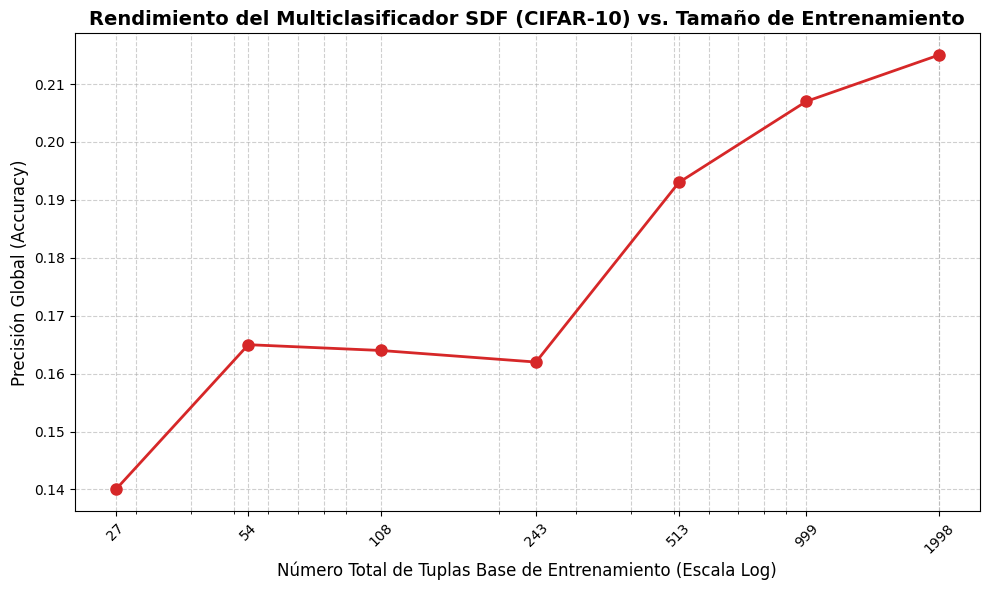

In [5]:
# ==========================================
# 3. GENERACIÓN DE GRÁFICA DE RENDIMIENTO
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(history_total_images, history_accuracy, marker='o', linestyle='-', color='#d62728', linewidth=2, markersize=8)

# Utilizamos escala logarítmica para visualizar el barrido asintótico
plt.xscale('log')
plt.xticks(history_total_images, history_total_images, rotation=45)

plt.title('Rendimiento del Multiclasificador SDF (CIFAR-10) vs. Tamaño de Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Número Total de Tuplas Base de Entrenamiento (Escala Log)', fontsize=12)
plt.ylabel('Precisión Global (Accuracy)', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

#Tutorial: Clasificación Binaria en CIFAR-10 mediante SDF

A diferencia de la clasificación multiclase, donde un solo filtro debe discriminar su clase contra las otras 9 simultáneamente, la clasificación binaria simplifica la carga paramétrica del filtro SDF. En este escenario, enfrentamos pares de clases (Uno-contra-Uno). Al reducir drásticamente el número de imágenes de entrenamiento (10 verdaderas y 5 falsas), el tamaño de la matriz cruzada $X$ disminuye lo suficiente como para resolver el sistema algebraico directamente, sin necesidad de aplicar reducción de dimensionalidad (SVD) para evitar el colapso de la memoria RAM.

##1. Parámetros Físicos y la Arquitectura del Correlador 4f

In [6]:
import numpy as np
import time
import pandas as pd
from numpy.fft import fft2, ifft2, fftshift
from sklearn.metrics import accuracy_score
import tensorflow as tf

final_size = 128
d = final_size * final_size

num_variaciones = 10  # Imágenes de la clase objetivo (Verdaderas)
num_falsos = 5        # Imágenes de la clase a rechazar (Falsas)
d_s = 8
desplazamientos = [(0, 0), (d_s, 0), (-d_s, 0), (0, d_s), (0, -d_s)]

# El tamaño total del filtro ahora es muy pequeño: (10 + 5) * 5 = 75 columnas
total_images_in_filter = (num_variaciones + num_falsos) * len(desplazamientos)
images_per_class_test = 100

def optical_correlator(input_img, target_img):
    """Simulador óptico 4f optimizado."""
    U_in_focal = np.fft.fft2(input_img)
    target_spectrum = np.fft.fft2(target_img)

    # El conjugado complejo simula el filtro holográfico invertido
    H_filter = np.conj(target_spectrum)

    U_filtered = U_in_focal * H_filter
    U_out = np.fft.fftshift(np.fft.ifft2(U_filtered))

    # Los sensores ópticos miden intensidad (amplitud al cuadrado)
    return np.abs(U_out)**2

##2. Aplanamiento de Etiquetas y Separación Global

In [8]:
labels_flat_train = train_labels.flatten()
labels_flat_test = test_labels.flatten()

print("Iniciando separación estructurada de datos CIFAR-10 (Clases 0 al 9)...")
np.random.seed(42)

idx_train_all = {i: [] for i in range(10)}
idx_test_all = {i: [] for i in range(10)}

for clase in range(10):
    # Buscar y mezclar en el set de prueba original
    idx_clase_test = np.where(labels_flat_test == clase)[0]
    np.random.shuffle(idx_clase_test)

    # Buscar y mezclar en el set de entrenamiento original
    idx_clase_train = np.where(labels_flat_train == clase)[0]
    np.random.shuffle(idx_clase_train)

    # Extraemos 100 imágenes para evaluar por clase
    idx_test_all[clase] = idx_clase_test[:images_per_class_test]

    # Todo el bloque de entrenamiento queda disponible
    idx_train_all[clase] = idx_clase_train

# Inicialización de la matriz de resultados 10x10
accuracy_matrix = np.full((10, 10), 'X', dtype=object)
for i in range(10):
    accuracy_matrix[i, i] = 1.0

Iniciando separación estructurada de datos CIFAR-10 (Clases 0 al 9)...


##3. Solución Analítica Directa y Bucle de 45 Combinaciones

Este bucle iterativo evalúa todas las permutaciones posibles en el triángulo superior de la matriz de confusión (Clase 0 vs 1, Clase 0 vs 2... hasta Clase 8 vs 9).
**Nota Matemática**: A diferencia del clasificador multiclase de CIFAR-10, aquí la matriz cruzada $X$ solo tiene 75 columnas. La matriz de covarianza $R = X^T X$ es de apenas $75 \times 75$. Esto permite omitir el uso de `TruncatedSVD` y aplicar una regularización de Tikhonov directa (`lambda_reg = 1e-4 * np.trace(R)`). Este paso asegura que la pseudoinversa (`np.linalg.pinv`) sea numéricamente estable sin sacrificar información geométrica.

In [9]:
# ==========================================
# 2. BUCLE PRINCIPAL (45 COMBINACIONES BINARIAS)
# ==========================================
start_time_total = time.time()
print("\nIniciando síntesis iterativa y evaluación de matriz SDF para CIFAR-10...")

for clase_A in range(10):
    for clase_B in range(clase_A + 1, 10):
        print(f"\n---> Evaluando par: {clase_A} vs {clase_B}")

        # --- SÍNTESIS DE FILTROS ---
        reference_images_sdf = {}
        for clase_objetivo in [clase_A, clase_B]:
            clase_falsa = clase_B if clase_objetivo == clase_A else clase_A

            X = np.zeros((d, total_images_in_filter))
            u_list = []
            col = 0

            # 1. Objetivos Verdaderos (Exigencia = 1 solo en el origen)
            for idx in idx_train_all[clase_objetivo][:num_variaciones]:
                img_padded = pad_image(train_images_2d[idx], final_size)
                img_norm = zero_mean_normalize(img_padded)

                for dy, dx in desplazamientos:
                    img_shifted = np.roll(img_norm, shift=(dy, dx), axis=(0, 1))
                    X[:, col] = img_shifted.flatten()
                    u_list.append(1.0 if dy == 0 and dx == 0 else 0.0)
                    col += 1

            # 2. Objetivos Falsos (Exigencia = 0 en todo el plano)
            for idx in idx_train_all[clase_falsa][:num_falsos]:
                img_padded = pad_image(train_images_2d[idx], final_size)
                img_norm = zero_mean_normalize(img_padded)

                for dy, dx in desplazamientos:
                    img_shifted = np.roll(img_norm, shift=(dy, dx), axis=(0, 1))
                    X[:, col] = img_shifted.flatten()
                    u_list.append(0.0)
                    col += 1

            # 3. Solución directa del sistema algebraico (Sin SVD)
            u = np.array(u_list)
            R = X.T @ X

            # Regularización de Tikhonov
            lambda_reg = 1e-4 * np.trace(R)
            R_inv = np.linalg.pinv(R + lambda_reg * np.eye(total_images_in_filter))

            a = R_inv @ u
            h_1d = X @ a
            reference_images_sdf[clase_objetivo] = h_1d.reshape((final_size, final_size))

        # --- CLASIFICACIÓN ÓPTICA BINARIA ---
        # Unimos las 100 imágenes de prueba de la clase A y las 100 de la clase B
        indices_prueba_par = np.concatenate([idx_test_all[clase_A], idx_test_all[clase_B]])
        y_true = []
        y_pred = []

        for idx in indices_prueba_par:
            test_img = pad_image(test_images_2d[idx], final_size)
            test_img_norm = zero_mean_normalize(test_img)
            true_label = int(labels_flat_test[idx])

            # Pase por el correlador óptico simulado contra ambos filtros
            int_A = np.max(optical_correlator(test_img_norm, reference_images_sdf[clase_A]))
            int_B = np.max(optical_correlator(test_img_norm, reference_images_sdf[clase_B]))

            # Decisión final por discriminación de máxima energía
            predicted_digit = clase_A if int_A > int_B else clase_B
            y_true.append(true_label)
            y_pred.append(predicted_digit)

        # Cálculo de Accuracy para el par evaluado
        acc = accuracy_score(y_true, y_pred)
        accuracy_matrix[clase_A, clase_B] = round(acc, 2)
        print(f"     Accuracy final ({clase_A} vs {clase_B}): {acc:.2f}")

elapsed_time_total = time.time() - start_time_total
print(f"\n==========================================")
print(f"TIEMPO TOTAL DEL BUCLE: {elapsed_time_total / 60:.2f} minutos")
print(f"==========================================\n")


Iniciando síntesis iterativa y evaluación de matriz SDF para CIFAR-10...

---> Evaluando par: 0 vs 1
     Accuracy final (0 vs 1): 0.57

---> Evaluando par: 0 vs 2
     Accuracy final (0 vs 2): 0.52

---> Evaluando par: 0 vs 3
     Accuracy final (0 vs 3): 0.62

---> Evaluando par: 0 vs 4
     Accuracy final (0 vs 4): 0.59

---> Evaluando par: 0 vs 5
     Accuracy final (0 vs 5): 0.57

---> Evaluando par: 0 vs 6
     Accuracy final (0 vs 6): 0.61

---> Evaluando par: 0 vs 7
     Accuracy final (0 vs 7): 0.55

---> Evaluando par: 0 vs 8
     Accuracy final (0 vs 8): 0.53

---> Evaluando par: 0 vs 9
     Accuracy final (0 vs 9): 0.59

---> Evaluando par: 1 vs 2
     Accuracy final (1 vs 2): 0.47

---> Evaluando par: 1 vs 3
     Accuracy final (1 vs 3): 0.54

---> Evaluando par: 1 vs 4
     Accuracy final (1 vs 4): 0.53

---> Evaluando par: 1 vs 5
     Accuracy final (1 vs 5): 0.58

---> Evaluando par: 1 vs 6
     Accuracy final (1 vs 6): 0.51

---> Evaluando par: 1 vs 7
     Accuracy fi

In [10]:
# ==========================================
# 3. IMPRESIÓN DE LA MATRIZ ESTILO ARTÍCULO
# ==========================================
# Se convierte la matriz numpy a un formato DataFrame de Pandas
columnas = [str(i) for i in range(10)]
df_accuracy = pd.DataFrame(accuracy_matrix, columns=columnas, index=columnas)

print("MATRIZ DE ACCURACY DE CLASIFICACIÓN BINARIA SDF (CIFAR-10):\n")
print(df_accuracy.to_string())

MATRIZ DE ACCURACY DE CLASIFICACIÓN BINARIA SDF (CIFAR-10):

     0     1     2     3     4     5     6     7     8     9
0  1.0  0.57  0.52  0.62  0.59  0.57  0.61  0.55  0.53  0.59
1    X   1.0  0.47  0.54  0.53  0.58  0.51  0.56  0.55  0.53
2    X     X   1.0  0.53  0.52  0.48  0.52  0.48  0.54  0.54
3    X     X     X   1.0  0.54  0.48  0.49  0.55  0.57  0.65
4    X     X     X     X   1.0  0.52  0.52  0.54  0.59  0.59
5    X     X     X     X     X   1.0  0.53   0.5  0.62  0.57
6    X     X     X     X     X     X   1.0  0.62  0.65  0.64
7    X     X     X     X     X     X     X   1.0  0.54  0.67
8    X     X     X     X     X     X     X     X   1.0  0.49
9    X     X     X     X     X     X     X     X     X   1.0
